<a href="https://colab.research.google.com/github/nunez1405/Data-science-projects/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so


# Download latest version
titanic = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv"

df =  pd.read_csv(titanic)
df


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...,...
882,0,2,Rev. Juozas Montvila,male,27.0,0,0,13.0000
883,1,1,Miss. Margaret Edith Graham,female,19.0,0,0,30.0000
884,0,3,Miss. Catherine Helen Johnston,female,7.0,1,2,23.4500
885,1,1,Mr. Karl Howell Behr,male,26.0,0,0,30.0000


In [ ]:
#Encontrando la cantidad de nombres por sexo:
cant_personas_sexo= df["Sex"].value_counts()
cant_personas_sexo

,count
Sex,
male,573
female,314


In [ ]:
#Agregando la columna largo que para cada nombre me de su largo
df['Size Name'] = df['Name'].apply(lambda x: len(x.strip()))
df.head()
#lambda argumentos: expresión

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Size Name
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500,22
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833,50
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250,21
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000,43
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500,23


In [ ]:
#Crear una tabla que refleje los nombres de las personas por genero, seleccionando el más largo y el más corto
# 1) Calcular largo mínimo y máximo por sexo
stats = df.groupby('Sex')['Size Name'].agg(minimo='min', maximo='max')

# 2) Para cada sexo, obtener los índices de la fila con largo mínimo y máximo
idx_min = df.groupby('Sex')['Size Name'].idxmin()
idx_max = df.groupby('Sex')['Size Name'].idxmax()

# 3) Extraer los nombres
minimos = df.loc[idx_min, ['Sex','Name','Size Name']].assign(Type='Shortest Name')
maximos = df.loc[idx_max, ['Sex','Name','Size Name']].assign(Type='Longest Name')

# 4) Unir ambos resultados
resultado = pd.concat([minimos, maximos]).reset_index(drop=True)
resultado

,Sex,Name,Size Name,Type
0,female,Miss. Anna Ward,15,Shortest Name
1,male,Mr. Ali Lam,11,Shortest Name
2,female,Mrs. Victor de Satode (Maria Josefa Perez de S...,81,Longest Name
3,male,Mr. Charles Frederick Waddington Sedgwick,41,Longest Name


In [ ]:
"¿Cuál es el largo más común? Poné algunos ejemplos"
#obtencion de una serie con el largo mas grande como indice y las veces que aparece
largo_comun = df['Size Name'].value_counts().head(1)
# Extraer el valor de largo más común
valor_largo = largo_comun.index[0]
#cant de nombres con ese largo:

# Ejemplos de nombres con ese largo
ejemplos = df[df['Size Name'] == valor_largo].head(10)
print("Largo más común y cantidad:")
largo_comun
print("\nEjemplos de nombres con ese largo:")
print(ejemplos[['Name', 'Sex', 'Size Name']])
cantidad = largo_comun.values[0]
largo_comun


Largo más común y cantidad:

Ejemplos de nombres con ese largo:
                   Name     Sex  Size Name
22   Miss. Anna McGowan  female         18
29   Mr. Lalio Todoroff    male         18
47   Mr. Youssef Samaan    male         18
56   Mr. Mansouer Novel    male         18
60   Miss. Amelie Icard  female         18
83   Miss. Bertha Ilett  female         18
108  Miss. Bertha Moran  female         18
122  Miss. Susan Webber  female         18
125  Mr. Martin McMahon    male         18
137  Mr. Olaf Elon Osen    male         18


,count
Size Name,
18,68


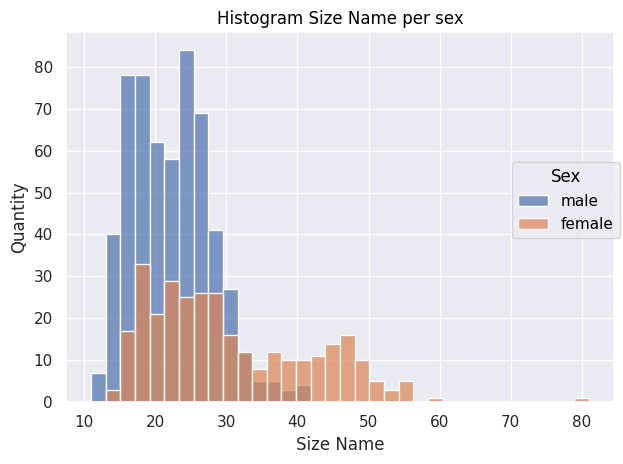

In [ ]:
#Histograma de Largo y coloreado por sexo :
(
    so.Plot(df, x="Size Name", color="Sex")
    .add(so.Bars(), so.Hist())
    .label(x="Size Name", y="Quantity", title="Histogram Size Name per sex")
    .show()
)

In [ ]:
# Eliminamos espacios antes y después del nombre, y pasamos a minúsculas
df['Name'] = df['Name'].str.strip().str.lower()

# Ahora filtramos los que NO contienen espacios en el medio (nombre simple)
nombres_simples = df[~df['Name'].str.contains(' ')]

# Repetimos el punto 4 sobre estos nombres simples
mas_corto = nombres_simples.loc[nombres_simples.groupby("Sex")["Size Name"].idxmin()]
mas_largo = nombres_simples.loc[nombres_simples.groupby("Sex")["Size Name"].idxmax()]

print("Nombres simples más cortos por género:")
print(mas_corto[['Name', 'Sex', 'Size Name']])

print("\nNombres simples más largos por género:")
print(mas_largo[['Name', 'Sex', 'Size Name']])


Nombres simples más cortos por género:
Empty DataFrame
Columns: [Name, Sex, Size Name]
Index: []

Nombres simples más largos por género:
Empty DataFrame
Columns: [Name, Sex, Size Name]
Index: []
